<a href="https://colab.research.google.com/github/sanjanaa2306/projects/blob/main/loan_approval_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/loan_approval_dataset.csv")
# Display unique values to check for discrepancies
print("Unique values in ' education' column before mapping:", df[" education"].unique())
print("Unique values in ' loan_status' column before mapping:", df[" loan_status"].unique())
print("Unique values in ' self_employed' column before mapping:", df[" self_employed"].unique())

df[" education"] = df[" education"].map({" Graduate": 1," Not Graduate": 0})
df[" loan_status"] = df[" loan_status"].map({" Approved": 1," Rejected": 0})
df[" self_employed"]=df[" self_employed"].map({" Yes":1," No":0})
df

Unique values in ' education' column before mapping: [' Graduate' ' Not Graduate']
Unique values in ' loan_status' column before mapping: [' Approved' ' Rejected']
Unique values in ' self_employed' column before mapping: [' No' ' Yes']


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,1,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,4266,0,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,4267,2,0,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,4268,1,0,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1


In [ ]:
# Remove loan_id column (already removed, so this line is redundant)
# df = df.drop("loan_id", axis=1) # This line was causing the error
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,1,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,4266,0,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,4267,2,0,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,4268,1,0,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1


In [ ]:
# Features
X = df.drop(" loan_status", axis=1)

# Target
y = df[" loan_status"]

# Display
print("FEATURES")
print(X.head())

print("\nTARGET")
print(y.head())

FEATURES
   loan_id   no_of_dependents   education   self_employed   income_annum  \
0        1                  2           1               0        9600000   
1        2                  0           0               1        4100000   
2        3                  3           1               0        9100000   
3        4                  3           1               0        8200000   
4        5                  5           0               1        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_value  
0                  17600000   

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display shapes

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3415, 12)
X_test shape: (854, 12)
y_train shape: (3415,)
y_test shape: (854,)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Fit and transform training data
X_train = scaler.fit_transform(X_train)

# Transform testing data
X_test = scaler.transform(X_test)

print("Scaling completed")

Scaling completed


In [ ]:
# LOGISTIC REGRESSION - COMPLETE CODE
# Import library
from sklearn.linear_model import LogisticRegression
# CREATE MODEL
lr_model = LogisticRegression()
# TRAIN MODEL
lr_model.fit(X_train, y_train)
print("Model trained successfully")
y_pred = lr_model.predict(X_test)
print("\nPredicted Values:")
print(y_pred)
# ACTUAL VALUES
print("\nActual Values:")
print(y_test.values)

Model trained successfully

Predicted Values:
[0 1 0 1 1 1 1 0 1 0 1 1 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 1 1 0 1 0 1 1 0 0 1
 1 1 0 0 1 1 1 0 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1
 0 1 0 0 1 1 0 0 0 1 0 0 1 1 0 0 1 0 1 1 0 1 0 1 1 0 1 1 1 1 0 1 0 1 1 1 1
 1 0 0 0 0 1 1 1 1 0 0 0 0 1 1 1 0 0 1 1 0 1 0 0 1 1 0 1 1 1 1 1 0 0 1 0 1
 1 1 1 1 0 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 1 0 1 0 0 1 0 0 0
 1 1 1 0 1 1 0 0 0 1 1 0 1 1 1 0 0 0 0 0 0 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1
 1 1 1 1 1 0 1 0 1 0 0 0 1 1 1 1 0 1 0 0 1 1 1 0 0 0 0 1 1 1 1 1 0 0 0 1 0
 1 1 1 1 0 1 1 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 0 1 1 1 1 1 0 0 1 1 1 0 1 0 1
 1 0 0 0 0 0 1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 0 0 1 0 0 0 1 0 1
 1 1 0 0 1 1 1 1 1 0 1 1 0 0 1 1 0 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 1 1
 1 0 1 0 0 0 0 0 1 0 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 0 1 1 1 0
 0 1 1 0 1 1 0 1 0 0 0 0 1 0 0 0 1 1 1 0 1 1 1 0 1 1 1 0 0 0 0 1 1 0 1 1 0
 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 0 0 0 1 1

In [ ]:

# LOGISTIC REGRESSION
# Import libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
# CREATE MODEL
lr_model = LogisticRegression()
# TRAIN MODEL
lr_model.fit(X_train, y_train)
print("Model trained successfully")
# MAKE PREDICTIONS
y_pred = lr_model.predict(X_test)
print("\nPredicted Values:")
print(y_pred)
# CALCULATE ACCURACY
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:")
print(accuracy)
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
# CLASSIFICATION REPORT
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model trained successfully

Predicted Values:
[0 1 0 1 1 1 1 0 1 0 1 1 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 1 1 0 1 0 1 1 0 0 1
 1 1 0 0 1 1 1 0 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1
 0 1 0 0 1 1 0 0 0 1 0 0 1 1 0 0 1 0 1 1 0 1 0 1 1 0 1 1 1 1 0 1 0 1 1 1 1
 1 0 0 0 0 1 1 1 1 0 0 0 0 1 1 1 0 0 1 1 0 1 0 0 1 1 0 1 1 1 1 1 0 0 1 0 1
 1 1 1 1 0 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 1 0 1 0 0 1 0 0 0
 1 1 1 0 1 1 0 0 0 1 1 0 1 1 1 0 0 0 0 0 0 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1
 1 1 1 1 1 0 1 0 1 0 0 0 1 1 1 1 0 1 0 0 1 1 1 0 0 0 0 1 1 1 1 1 0 0 0 1 0
 1 1 1 1 0 1 1 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 0 1 1 1 1 1 0 0 1 1 1 0 1 0 1
 1 0 0 0 0 0 1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 0 0 1 0 0 0 1 0 1
 1 1 0 0 1 1 1 1 1 0 1 1 0 0 1 1 0 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 1 1
 1 0 1 0 0 0 0 0 1 0 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 0 1 1 1 0
 0 1 1 0 1 1 0 1 0 0 0 0 1 0 0 0 1 1 1 0 1 1 1 0 1 1 1 0 0 0 0 1 1 0 1 1 0
 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 0 0 0 1 1

In [ ]:
# DECISION TREE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
# Create model
dt_model = DecisionTreeClassifier(random_state=42)
# Train model
dt_model.fit(X_train, y_train)
print("Decision Tree trained successfully")
# Predictions
dt_pred = dt_model.predict(X_test)
# Accuracy
dt_accuracy = accuracy_score(y_test, dt_pred)
print("\nDecision Tree Accuracy:")
print(dt_accuracy)
# Confusion Matrix
print("\nDecision Tree Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

# Classification Report
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree trained successfully

Decision Tree Accuracy:
0.9742388758782201

Decision Tree Confusion Matrix:
[[308  10]
 [ 12 524]]

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       318
           1       0.98      0.98      0.98       536

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



In [ ]:
# RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
# Train model
rf_model.fit(X_train, y_train)
print("\nRandom Forest trained successfully")
# Predictions
rf_pred = rf_model.predict(X_test)
# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)
print("\nRandom Forest Accuracy:")
print(rf_accuracy)
# Confusion Matrix
print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
# Classification Report
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))


Random Forest trained successfully

Random Forest Accuracy:
0.9800936768149883

Random Forest Confusion Matrix:
[[309   9]
 [  8 528]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       318
           1       0.98      0.99      0.98       536

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [ ]:
print("Logistic Regression Accuracy :", accuracy)
print("Decision Tree Accuracy       :", dt_accuracy)
print("Random Forest Accuracy       :", rf_accuracy)

Logistic Regression Accuracy : 0.9074941451990632
Decision Tree Accuracy       : 0.9742388758782201
Random Forest Accuracy       : 0.9800936768149883


In [ ]:
# XGBOOST CLASSIFIER
# Install xgboost first if needed:
# pip install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
# CREATE MODEL
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
# TRAIN MODEL
xgb_model.fit(X_train, y_train)
print("XGBoost model trained successfully")
# MAKE PREDICTIONS
xgb_pred = xgb_model.predict(X_test)
# ACCURACY
xgb_accuracy = accuracy_score(y_test, xgb_pred)
print("\nXGBoost Accuracy:")
print(xgb_accuracy)
# CONFUSION MATRIX
print("\nXGBoost Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))
# CLASSIFICATION REPORT
print("\nXGBoost Classification Report:")
print(classification_report(y_test, xgb_pred))

XGBoost model trained successfully

XGBoost Accuracy:
0.9765807962529274

XGBoost Confusion Matrix:
[[306  12]
 [  8 528]]

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       318
           1       0.98      0.99      0.98       536

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854



                      Feature  Importance
7                 cibil_score    0.802266
6                   loan_term    0.061307
5                 loan_amount    0.027715
0                     loan_id    0.017164
10        luxury_assets_value    0.016837
4                income_annum    0.016744
8    residential_assets_value    0.016071
11           bank_asset_value    0.015433
9     commercial_assets_value    0.014508
1            no_of_dependents    0.007575
2                   education    0.002300
3               self_employed    0.002079


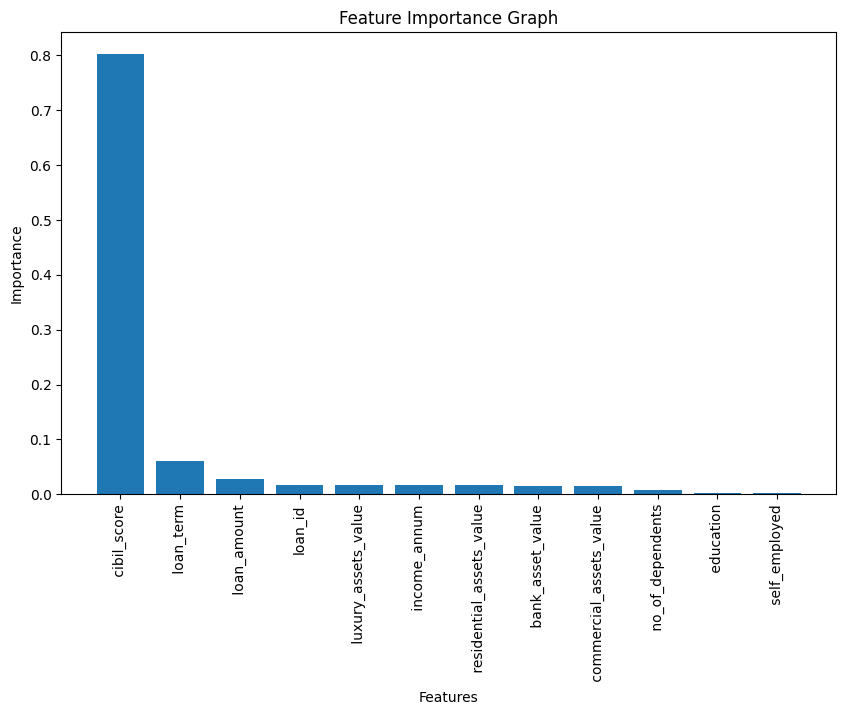

In [ ]:
#Feature importance graph
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = rf_model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Print values
print(feature_importance)

# Plot graph
plt.figure(figsize=(10,6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xticks(rotation=90)

plt.xlabel("Features")
plt.ylabel("Importance")

plt.title("Feature Importance Graph")

plt.show()

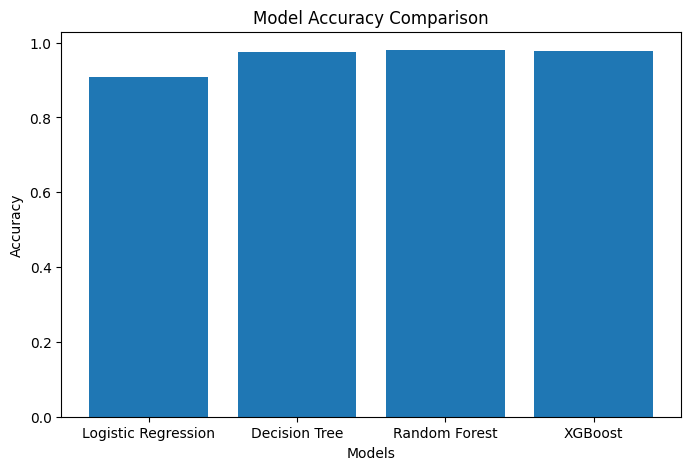

In [ ]:
#Accuracy comparision graph
import matplotlib.pyplot as plt
# Model names
models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost"
]
# Accuracy values
accuracies = [
    accuracy,
    dt_accuracy,
    rf_accuracy,
    xgb_accuracy
]
# Plot graph
plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

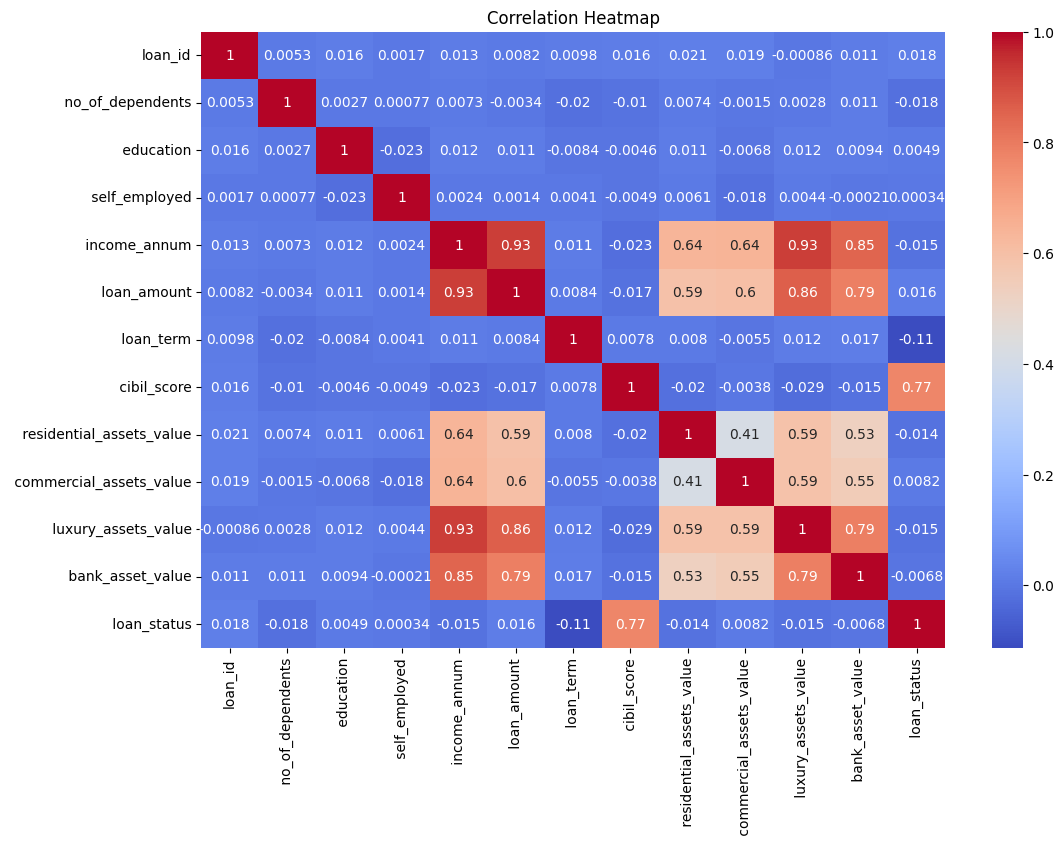

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Correlation matrix
corr = df.corr()
# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()